I0000 00:00:1789678613.751515    1712 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789678627.288219    1712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789678636.991081    1712 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789678644.861859    1712 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: 

Training model... this may take a few seconds.
Training complete.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


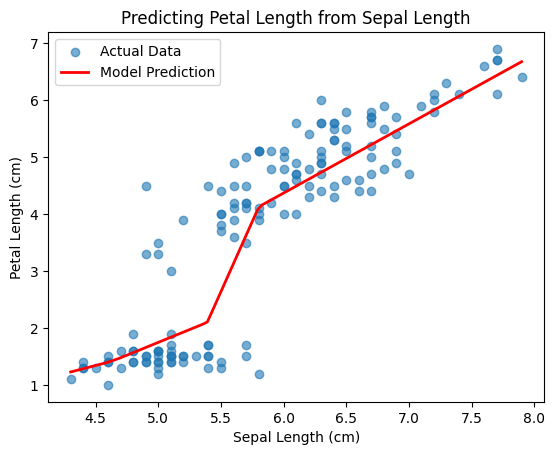

In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# 1. Load and wrangle the Iris dataset
iris = datasets.load_iris()

# Feature 0: Sepal Length, Feature 2: Petal Length
# We reshape them to (-1, 1) to ensure they are 2D column arrays for Keras
X = iris.data[:, 0].reshape(-1, 1)  # Input: Sepal Length
y = iris.data[:, 2].reshape(-1, 1)  # Output: Petal Length

# 2. Define the Keras model
model = Sequential()
model.add(Dense(16, input_dim=1, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# 3. Compile the Keras model
# A learning rate of 0.01 often converges well for this specific Iris regression
opt = optimizers.Adam(learning_rate=0.01)
mse = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)

# 4. Fit the Keras model on the dataset
print("Training model... this may take a few seconds.")
model.fit(X, y, epochs=1000, batch_size=10, verbose=0)
print("Training complete.")

# 5. Make predictions over a smooth grid of sepal lengths for plotting
x_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(x_grid)

# 6. Plot the results
plt.scatter(X, y, label='Actual Data', alpha=0.6)
plt.plot(x_grid, y_pred, color='red', label='Model Prediction', linewidth=2)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Predicting Petal Length from Sepal Length')
plt.legend()
plt.show()